In [18]:
import torch

inputs=torch.tensor(
    [
        [0.43,0.15,0.89], #your
        [0.55,0.87,0.66], #journey
        [0.57,0.85,0.64], #starts
        [0.22,0.58,0.33] , # with
        [0.77,0.25,0.10] , #one
        [0.05,0.80,0.55] #step
    ]
)

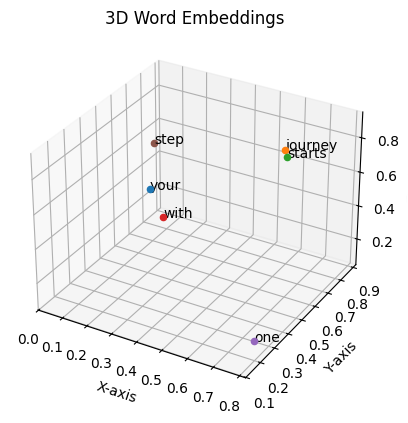

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D #3D plotting toolkit

words=["your","journey","starts","with","one","step"]

x_coords=inputs[:,0].numpy() #x coordinates
y_coords=inputs[:,1].numpy() #y coordinates
z_coords=inputs[:,2].numpy() #z coordinates


fig=plt.figure() #create a new figure
ax=fig.add_subplot(111,projection='3d') #add a 3D subplot

for x,y,z,word in zip(x_coords,y_coords,z_coords,words):
    ax.scatter(x,y,z) #plot the point
    ax.text(x,y,z,word,fontsize=10) #add the word as a label

ax.set_xlabel('X-axis') #label x-axis
ax.set_ylabel('Y-axis') #label y-axis
ax.set_zlabel('Z-axis') #label z-axis

plt.title('3D Word Embeddings') #set title
plt.show() #display the plot

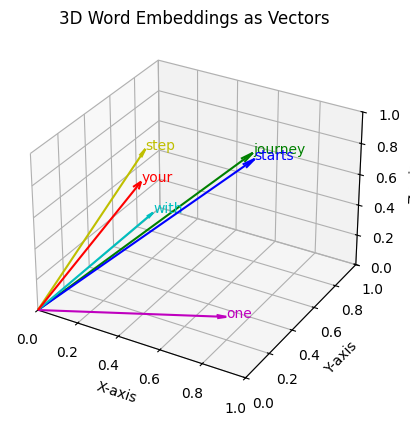

In [20]:
fig=plt.figure() #create a new figure
ax=fig.add_subplot(111,projection='3d') #add a 3D subplot

colors=['r','g','b','c','m','y'] #colors for each point 

for(x,y,z,word,color) in zip(x_coords,y_coords,z_coords,words,colors):
    ax.quiver(0,0,0,x,y,z,color=color,arrow_length_ratio=0.05) #plot a vector from origin to the point
    ax.text(x,y,z,word,fontsize=10,color=color) #add the word as a label

ax.set_xlabel('X-axis') #label x-axis
ax.set_ylabel('Y-axis') #label y-axis
ax.set_zlabel('Z-axis') #label z-axis

ax.set_xlim([0,1]) #set x-axis limits
ax.set_ylim([0,1]) #set y-axis limits
ax.set_zlim([0,1]) #set z-axis limits

plt.title('3D Word Embeddings as Vectors') #set title
plt.show() #display the plot

In [21]:
query=inputs[1] #embedding for "journey"

attn_scores_2=torch.empty(inputs.shape[0]) #initialize attention scores
for i,x_i in enumerate(inputs): # iterate over each word embedding
    attn_scores_2[i]=torch.dot(x_i,query) # compute dot product with the query

print("Attention Scores:", attn_scores_2) # print the attention scores

Attention Scores: tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [22]:
attn_weights_2_tmp=attn_scores_2/attn_scores_2.sum() #normalize attention scores to get weights

print("Attention Weights:", attn_weights_2_tmp) # print the attention weights
print("Sum of Attention Weights:", attn_weights_2_tmp.sum()) # verify that weights sum to 1 


Attention Weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum of Attention Weights: tensor(1.0000)


In [23]:
def softmax_naive(x): 
    return torch.exp(x) / torch.exp(x).sum(dim=0) # compute softmax by exponentiating and normalizing

attn_weights_2_naive=softmax_naive(attn_scores_2)

print("Attention weights:",attn_weights_2_naive)
print("Sum:",attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [24]:
attn_weights_2=torch.softmax(attn_scores_2,dim=0) # apply softmax to get attention weights
print("Attention Weights:", attn_weights_2) # print the attention weights

Attention Weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [25]:
query=inputs[1] #embedding for "journey" 

context_vec_2=torch.zeros(query.shape) #initialize context vector
for i,x_i in enumerate(inputs):
    context_vec_2+=attn_weights_2[i]*x_i # compute weighted sum of input embeddings
print("Context Vector:", context_vec_2) # print the context vector

Context Vector: tensor([0.4419, 0.6515, 0.5683])


In [ ]:
# here we compute the attention score using dot product ansd we does the matrix multipliocation using the for loop

attn_scores = torch.empty(inputs.shape[0], inputs.shape[0]) # initialize a matrix to hold attention scores for all pairs of input embeddings

for i, x_i in enumerate(inputs): # iterate over each input embedding as the query
    for j, x_j in enumerate(inputs): # iterate over each input embedding as the key
        attn_scores[i, j] = torch.dot(x_i, x_j) # compute the dot product between the query and key to get the attention score

print(attn_scores) 

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [28]:
# nnpw we can compute the  attn scores by doung ddot prouct using the matrix multiplication usiing linear algebra

attn_scores=inputs @ inputs.T # compute attention scores using matrix multiplication we multioy the input matrix with its transpose to get the attention scores for all pairs of embeddings at once

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [ ]:
attn_weights=torch.softmax(attn_scores,dim=-1) # apply softmax to each row to get attention weights for each query
# what diff comes if i do dim=0 instead of dim=1 ans - if we do dim=0, we would be applying softmax across columns instead of rows, which would give us attention weights that sum to 1 for each key instead of each query. This would not be correct for the self-attention mechanism, as we want the weights to sum to 1 for each query to properly compute the context vector.
# what is diff betwwen dim 0 , 1 & -1 - dim=0 applies softmax across columns (for each key), dim=1 applies softmax across rows (for each query), and dim=-1 applies softmax across the last dimension of the tensor, which in this case is the same as dim=1 since we have a 2D matrix. In the context of self-attention, we want to apply softmax across rows to get attention weights that sum to 1 for each query, so we should use dim=1 or dim=-1.
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [35]:
row_2_sum=attn_weights[2].sum() # sum of attention weights for the third query

print(row_2_sum)
print(attn_weights[2]) # print the attention weights for the third query to verify they sum to 1

tensor(1.0000)
tensor([0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565])


In [37]:
all_context_vecs=attn_weights @ inputs
print("All Context Vectors:\n", all_context_vecs) # print all context vectors

All Context Vectors:
 tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
